# Logistic Regression

## Synthetic two feature binary classification dataset.

`synthetic_binary.csv` is a synthetic (not-real) dataset for a binary classification task. The dataset has two continuous features `feature 1` and `feature 2`, and a binary output label `output`. 

---
## Step 1: Read the dataset and pre-process the features

We read in `synthetic_binary.csv`, build the `X_data` and `y_data` arrays, and split them with scikit-learn's [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html): first an 80-20 stratified split into train and test, then a further 80-20 stratified split of the training portion into train and validation. Stratifying keeps the class balance identical across all three sets, which matters here because the classes are not perfectly even.

Every split uses `random_state=20211008`, so the results below are reproducible.


In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import sklearn.metrics
from IPython.display import display
import matplotlib.pyplot as plt
%matplotlib inline

data_df = pd.read_csv('./synthetic_binary.csv')

display(data_df.head())

,feature 1,feature 2,output
0,-1.36,6.69,0.0
1,-8.12,-10.64,1.0
2,8.03,-9.94,1.0
3,-3.39,5.50,0.0
4,9.99,5.57,1.0


In [37]:
feat_df = data_df[['feature 1', 'feature 2']]
output_df = data_df['output']

# create X_data, y_data
X_data = feat_df.values
y_data = output_df.values

# split into train-val-test
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, train_size=0.8, random_state=20211008, stratify=y_data)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size=0.8, random_state=20211008, stratify=y_train)

print('X_data={}'.format(X_data.shape))
print('X_train={}, X_val={}, X_test={}'.format(X_train.shape, X_val.shape, X_test.shape))
print('y_train={}, y_val={}, y_test={}'.format(y_train.shape, y_val.shape, y_test.shape))
print()
print('class % in y_train = {}'.format((np.unique(y_train, return_counts=True)[1]/y_train.shape[0]).round(2)))
print('class % in y_val = {}'.format((np.unique(y_val, return_counts=True)[1]/y_val.shape[0]).round(2)))
print('class % in y_test = {}'.format((np.unique(y_test, return_counts=True)[1]/y_test.shape[0]).round(2)))

X_data=(550, 2)
X_train=(352, 2), X_val=(88, 2), X_test=(110, 2)
y_train=(352,), y_val=(88,), y_test=(110,)

class % in y_train = [0.45 0.55]
class % in y_val = [0.45 0.55]
class % in y_test = [0.45 0.55]


Text(0.5, 1.0, 'X_train Synthetic dataset for a binary classification two-feature task')

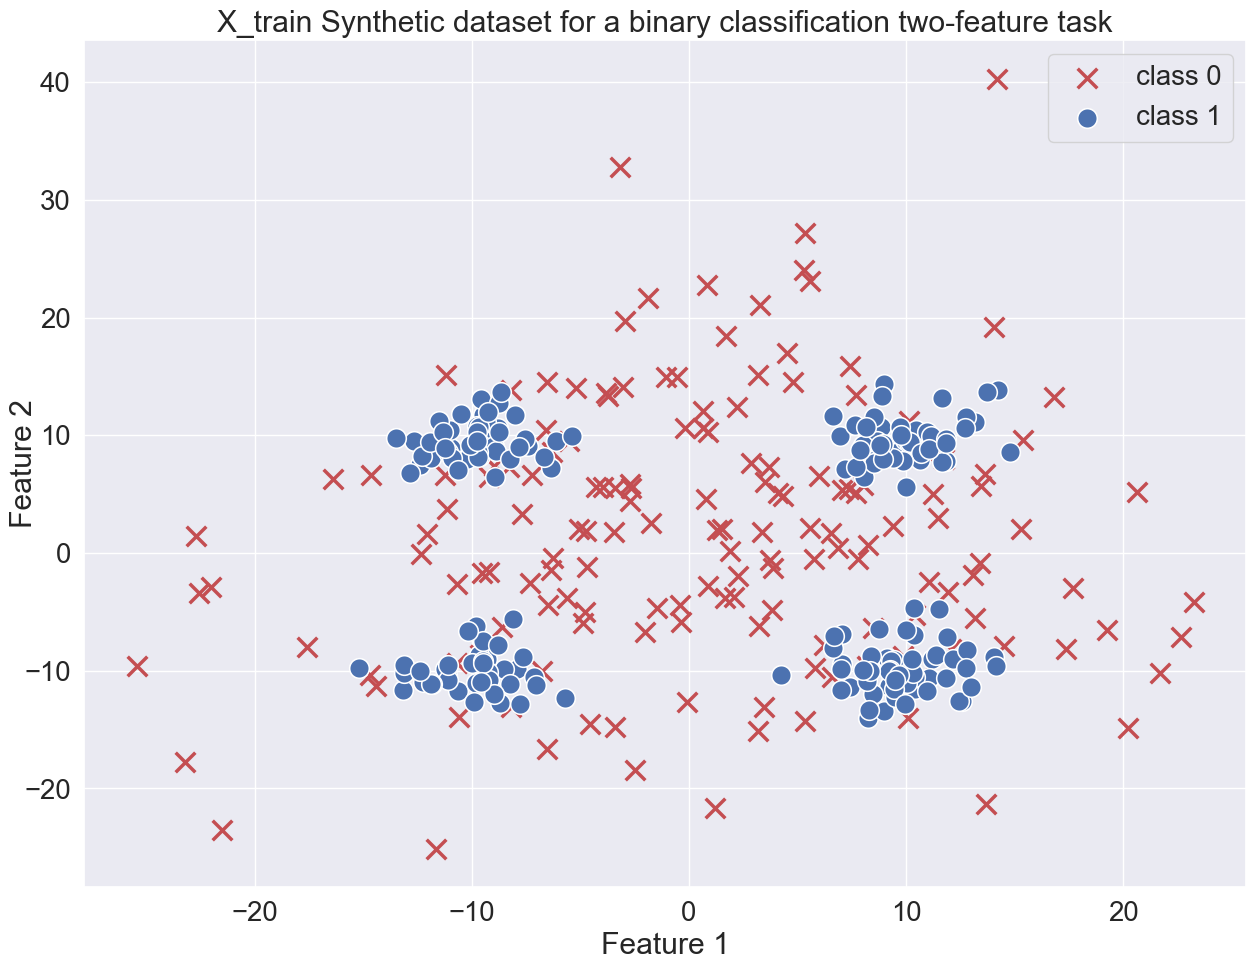

In [38]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("paper")
sns.set(font_scale=1.8)

plt.figure(figsize=(15,11))

X_train_1 = X_train[np.where(y_train==1)[0]]
X_train_0 = X_train[np.where(y_train==0)[0]]
sns.scatterplot(x = X_train_0[:,0], y = X_train_0[:,1], linewidth=2.5, marker='x', s=200, color='r', zorder=2, label='class 0')
sns.scatterplot(x = X_train_1[:,0], y = X_train_1[:,1], marker='o', s=200, color='b', zorder=2, label='class 1')

plt.ylabel('Feature 2', labelpad=-10)
plt.xlabel('Feature 1')
plt.title('X_train Synthetic dataset for a binary classification two-feature task')

---
## Step 2: Finding the best polynomial degree using the training and validation sets

Logistic regression draws a linear boundary, and the scatter plot above makes clear that a straight line will not separate these two classes. Expanding the features into polynomial terms lets a linear model curve its boundary in the original feature space.

We sweep over `degrees_list = [1, 2, 3, 4, 5, 6, 8, 9, 10]`, and for each degree:

- build polynomial features of the training and validation sets with [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)
- standard-scale the generated features with [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), fit on the training split only, since higher-degree terms differ wildly in magnitude
- fit [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) on the training features
- score it on the validation set with [accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)

The best degree is the one with the highest validation accuracy. The test set stays untouched until the degree is chosen.


In [39]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

degrees_list = [1, 2, 3, 4, 5, 6, 8, 9, 10]

best_degree = 1
best_acc = 0.0
for degree_val in degrees_list:
    # apply PolynomialFeatures to X_train and X_val
    poly = PolynomialFeatures(degree_val, include_bias=False) 

    X_train_poly = poly.fit_transform(X_train) 
    X_val_poly = poly.transform(X_val)  
    

    # standard-scale the generated poly features using StandardScaler
    scaler = StandardScaler()
    scaler.fit(X_train_poly)

    X_train_poly = scaler.transform(X_train_poly)
    X_val_poly = scaler.transform(X_val_poly)

    # fit LogReg on X_train_poly, y_train
    clf = LogisticRegression(random_state=20211008, max_iter=1000)
    clf.fit(X_train_poly, y_train)
    
    # evaluate on X_train_poly, y_train and X_val_poly, y_val
    y_pred_on_train = clf.predict(X_train_poly)
    train_acc = sklearn.metrics.accuracy_score(y_true=y_train, y_pred=y_pred_on_train)
    
    y_pred_on_val = clf.predict(X_val_poly)
    val_acc = sklearn.metrics.accuracy_score(y_true=y_val, y_pred=y_pred_on_val)
    
    print("Setting degree={}, train_acc={:.2f}, val_acc={:.2f}".format(degree_val, train_acc, val_acc))
    if val_acc > best_acc:
        best_acc = val_acc
        best_degree = degree_val
        
print("Best setting degree={}, val_acc={:.2f}".format(best_degree, best_acc))

Setting degree=1, train_acc=0.58, val_acc=0.56
Setting degree=2, train_acc=0.53, val_acc=0.51
Setting degree=3, train_acc=0.65, val_acc=0.62
Setting degree=4, train_acc=0.83, val_acc=0.80
Setting degree=5, train_acc=0.83, val_acc=0.81
Setting degree=6, train_acc=0.82, val_acc=0.81
Setting degree=8, train_acc=0.83, val_acc=0.81
Setting degree=9, train_acc=0.83, val_acc=0.81
Setting degree=10, train_acc=0.83, val_acc=0.81
Best setting degree=5, val_acc=0.81


In [40]:
# evaluate best degree on X_test, y_test

# merge train and val data
X_train_val_merge = np.vstack([X_train, X_val]) 
y_train_val_merge = np.hstack([y_train, y_val])
    
# apply PolynomialFeatures with best_degree
poly = PolynomialFeatures(best_degree, include_bias=False) 

X_train_poly = poly.fit_transform(X_train_val_merge) 
X_test_poly = poly.transform(X_test)

# standard-scale the generated poly features using StandardScaler
scaler = StandardScaler()
scaler.fit(X_train_poly)

X_train_poly = scaler.transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

# fit LogReg on X_train_poly, y_train
clf = LogisticRegression(random_state=20211008, max_iter=1000)
clf.fit(X_train_poly, y_train_val_merge)

# predict on X_test_poly, y_test
y_pred_on_test = clf.predict(X_test_poly)
test_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=y_pred_on_test)

print("Best setting degree={}, test_acc={:.2f}".format(best_degree, test_acc))

Best setting degree=5, test_acc=0.85


Text(0.5, 1.0, 'Polynomial Logistic Regression with degree=5. Test set is shown. test_acc=0.85')

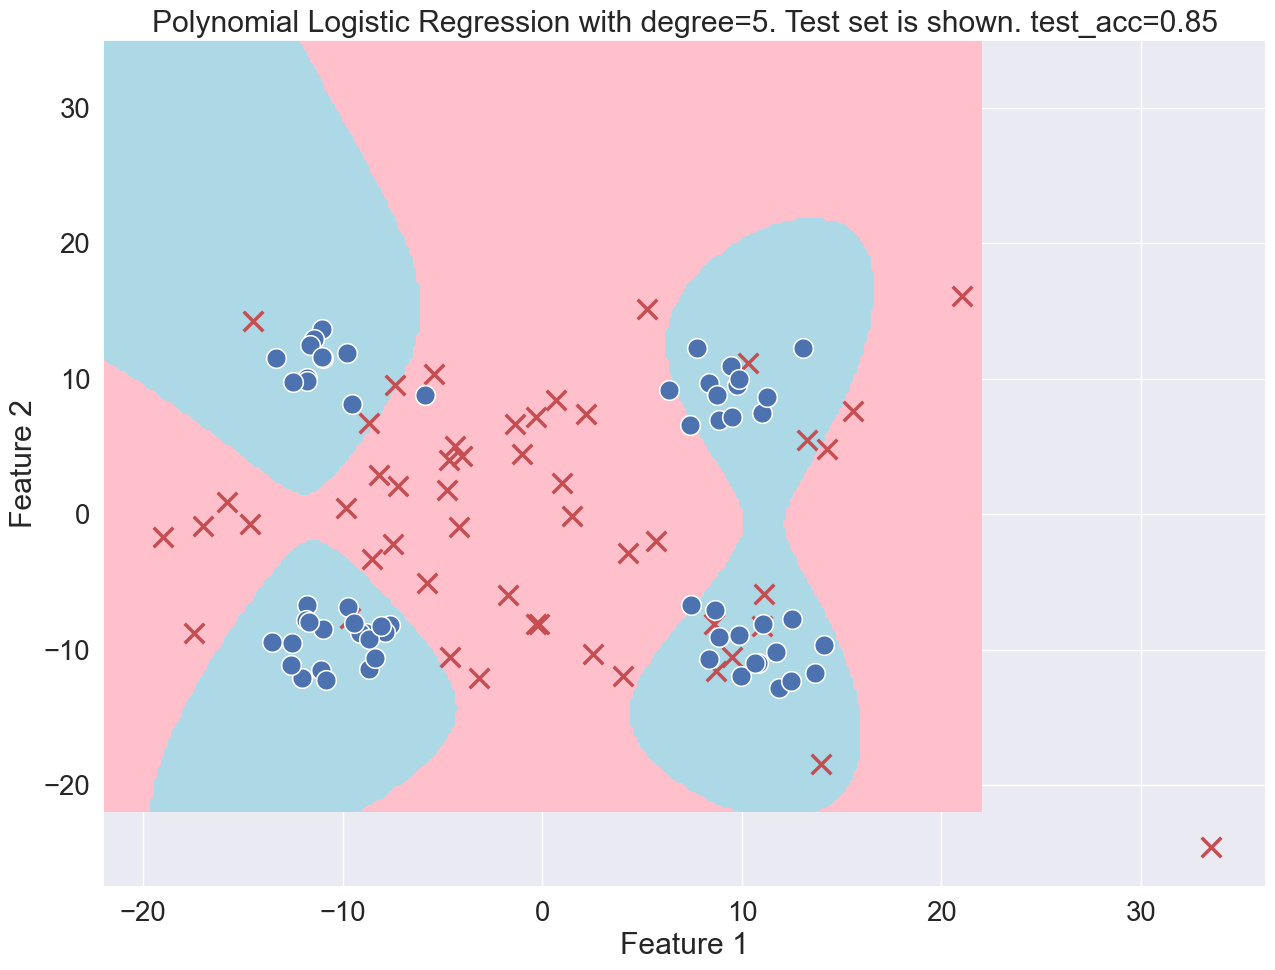

In [41]:
from matplotlib.colors import ListedColormap

lims = 22
x_pts = np.linspace(-lims, lims, 250)
y_pts = np.linspace(-lims, 35, 250)

xx, yy = np.meshgrid(x_pts, y_pts)
pts_init = np.c_[xx.ravel(), yy.ravel()]

#poly = PolynomialFeatures(best_degree, include_bias=False)
pts_poly = poly.transform(pts_init)
pts_poly_scaled = scaler.transform(pts_poly)

Z = clf.predict(pts_poly_scaled)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(15,11))
X_test1 = X_test[np.where(y_test==1)[0]]
X_test0 = X_test[np.where(y_test==0)[0]]

sns.scatterplot(x = X_test0[:,0], y = X_test0[:,1], linewidth=2.5, marker='x', s=200, color='r', zorder=2)
sns.scatterplot(x = X_test1[:,0], y = X_test1[:,1], marker='o', s=200, color='b', zorder=2)

cmap_light = ListedColormap(['pink', 'lightblue'])
plt.contourf(xx, yy, Z, cmap=cmap_light)

plt.ylabel('Feature 2')
plt.xlabel('Feature 1')
plt.title('Polynomial Logistic Regression with degree={}. Test set is shown. test_acc={:.2f}'.format(best_degree, test_acc))